In [1]:
#import urllib.request
#url = "https://raw.githubusercontent.com/mh2t/CS6140/refs/heads/main/data/Wine.csv"
#urllib.request.urlretrieve(url, "Wine.csv")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Question 1 - Data Pipeline and Variance Analysis

a) load_prepare function is written - this loads Wine dataset which should be on data folder. It then seperates target and features df and then we split train and test set in the ratio of 80/20 and then we apply scaler to normalise the features.

Oberservation: Proline had the largest value so it would be domaniating if not scaled.
Also noticed class 3 has only 6 samples in test set vs 14 and 16 in other Classes(1 and 2).

In [3]:
df = pd.read_csv("data/Wine.csv")
print(df.columns.tolist())
print(df.dtypes)
print(df.head(2))
#Last col is the taregt col, checking the values below
print(f"\nValues in last column: {df[df.columns[-1]].unique()}") #class labels, so this is the target col

['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline', 'Customer_Segment']
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
Customer_Segment          int64
dtype: object
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28     

In [4]:
def load_and_prepare(filepath, test_size=0.2, random_state=0):
    df =pd.read_csv(filepath)

    target_col = df.columns[-1]#not hard coding, we found the target and added it here
    feature_cols= df.columns[:-1]

    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X,y,test_size=test_size,random_state=random_state)
    
    
    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("\nClass distribution in y_train:", dict(zip(*np.unique(y_train, return_counts=True))))
    print("Class distribution in y_test: ", dict(zip(*np.unique(y_test, return_counts=True))))

    print("\nFeature stats Before vs After Scaling:")
    stats = []
    for col in feature_cols:
        stats.append({
            'Feature': col,
            'Mean (Before)': round(X_train[col].mean(), 3),
            'Std (Before)': round(X_train[col].std(), 3),
            'Mean (After)': round(X_train_scaled[:, list(feature_cols).index(col)].mean(), 3),
            'Std (After)': round(X_train_scaled[:, list(feature_cols).index(col)].std(), 3)
        })
    print(pd.DataFrame(stats).to_string(index=False))

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

filepath = "data/Wine.csv"
X_train, X_test, y_train, y_test, scaler = load_and_prepare(filepath)


X_train shape: (142, 13), X_test shape: (36, 13)
y_train shape: (142,), y_test shape: (36,)

Class distribution in y_train: {np.int64(1): np.int64(45), np.int64(2): np.int64(55), np.int64(3): np.int64(42)}
Class distribution in y_test:  {np.int64(1): np.int64(14), np.int64(2): np.int64(16), np.int64(3): np.int64(6)}

Feature stats Before vs After Scaling:
             Feature  Mean (Before)  Std (Before)  Mean (After)  Std (After)
             Alcohol         12.985         0.807          -0.0          1.0
          Malic_Acid          2.373         1.115           0.0          1.0
                 Ash          2.367         0.270          -0.0          1.0
        Ash_Alcanity         19.555         3.443          -0.0          1.0
           Magnesium        100.063        14.249          -0.0          1.0
       Total_Phenols          2.259         0.612          -0.0          1.0
          Flavanoids          1.949         0.976           0.0          1.0
Nonflavanoid_Phenols      

b) variance_analysis(X_train_scaled) wriiten - this function fits PCA with 13 components on scaled training data. The it plots invidiaul and cumulative variance.

Obervation: PC1 explains ~37% variance and then PC2 which has ~19% these 2 components >50% of the total variance. We need 10 components to reach 95% threshold specified. Then the cumulative curve shows the curve rising steaply up to PC3 and PC4 then starts to flaten after PC6 which means first few components carry most meaning.

Variance ratio per component:
  PC1: 0.3688 (36.88%)
  PC2: 0.1932 (19.32%)
  PC3: 0.1075 (10.75%)
  PC4: 0.0742 (7.42%)
  PC5: 0.0625 (6.25%)
  PC6: 0.0491 (4.91%)
  PC7: 0.0412 (4.12%)
  PC8: 0.0250 (2.50%)
  PC9: 0.0231 (2.31%)
  PC10: 0.0186 (1.86%)
  PC11: 0.0173 (1.73%)
  PC12: 0.0125 (1.25%)
  PC13: 0.0070 (0.70%)


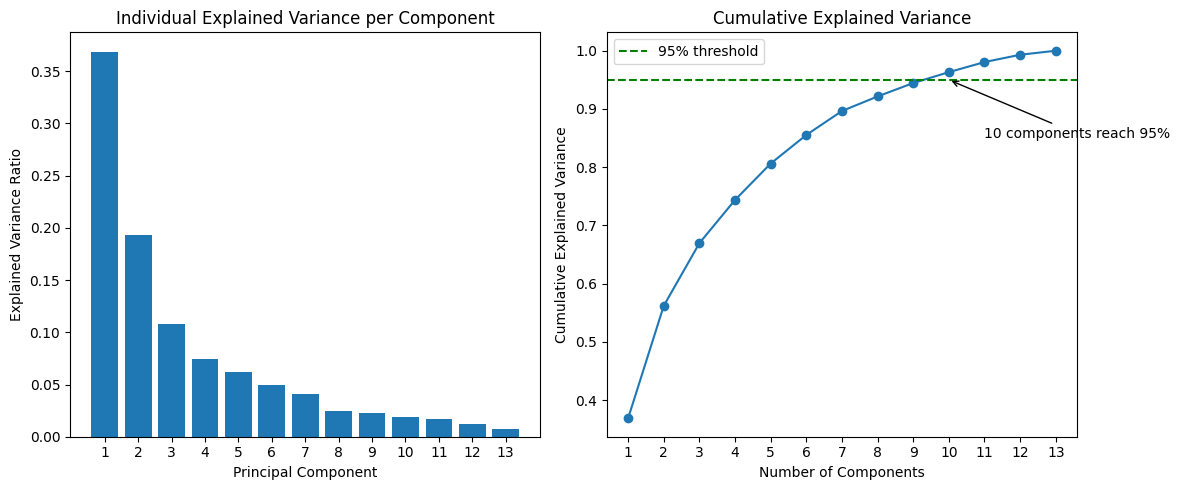


10 components needed to reach 95% variance


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def variance_analysis(X_train_scaled):
    pca = PCA(n_components=13)
    pca.fit(X_train_scaled)
    
    evr = pca.explained_variance_ratio_
    cumulative = np.cumsum(evr)
    n_95 = np.argmax(cumulative >= 0.95) + 1
    
    print("Variance ratio per component:")
    for i, v in enumerate(evr):
        print(f"  PC{i+1}: {v:.4f} ({v*100:.2f}%)")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.bar(range(1, 14), evr)
    ax1.set_xlabel("Principal Component")
    ax1.set_ylabel("Explained Variance Ratio")
    ax1.set_title("Individual Explained Variance per Component")
    ax1.set_xticks(range(1, 14))
    
    ax2.plot(range(1, 14), cumulative, marker='o')
    ax2.axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
    ax2.annotate(f'{n_95} components reach 95%', 
                 xy=(n_95, 0.95), xytext=(n_95+1, 0.85),
                 arrowprops=dict(arrowstyle='->'))
    ax2.set_xlabel("Number of Components")
    ax2.set_ylabel("Cumulative Explained Variance")
    ax2.set_title("Cumulative Explained Variance")
    ax2.set_xticks(range(1, 14))
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{n_95} components needed to reach 95% variance")
    return pca

pca = variance_analysis(X_train)


c)find_optimal_components(): this function finds min components needed to reach a given variance threshold using cumlative explained var. 

Obervation: going from 90% to 99% requires 4 extra components which only gains extra 9% more variance.

In [6]:
def find_optimal_components(X_train_scaled, variance_threshold=0.95):
    pca = PCA(n_components=13)
    pca.fit(X_train_scaled)
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumulative >= variance_threshold) + 1 # here we find how many components needed for to explain given variance
    return n_components

print(f"{'Threshold':<12} {'Components Required'}")
print("-" * 30)
for threshold in [0.90, 0.95, 0.99]:
    n = find_optimal_components(X_train, threshold)
    print(f"  {threshold:<10} {n}")


Threshold    Components Required
------------------------------
  0.9        8
  0.95       10
  0.99       12


## Question 2 - Classification with PCA

a)train_and_evalute()- this This function takes scaled train/test data and n_components, fits pca, then trains a Logistic Regression on the transformed data and evals on test set.

Observation: results show confusion maytrix with 0 misclassification and accuracy,recall & f1 of 100% which shows the dataset has clear distinction for its classes.

In [7]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(X_train, X_test, y_train, y_test, n_components):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    clf = LogisticRegression(random_state=0)
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"\nResults with {n_components} components")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return pca, clf, acc

pca_model, classifier, test_acc = train_and_evaluate(X_train, X_test, y_train, y_test, n_components=10)



Results with 10 components
Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


b)component_experiment()- this function loops through 13 components and record accuracy and cv for each and then plots it on twin y-axes

Observation: 1 component shows ~80% accuracy by 3 components we jump to 100% accuracy and stay. Another observation is after PC4 and Pc5 it drops to ~97% which shows extra component aded noise whcih confused the model.

Insight here varienace explained is not equal to classfication accuracy. Since Q1c shows we need 10 components to reach 95% variance but here we find we only need 3 components to get 100% accuracy.


Results with 1 components
Confusion Matrix:
[[11  3  0]
 [ 3 12  1]
 [ 0  0  6]]
Accuracy:  0.8056
Precision: 0.8143
Recall:    0.8452
F1-Score:  0.8277

Results with 2 components
Confusion Matrix:
[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]
Accuracy:  0.9722
Precision: 0.9778
Recall:    0.9792
F1-Score:  0.9778

Results with 3 components
Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Results with 4 components
Confusion Matrix:
[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]
Accuracy:  0.9722
Precision: 0.9778
Recall:    0.9792
F1-Score:  0.9778

Results with 5 components
Confusion Matrix:
[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]
Accuracy:  0.9722
Precision: 0.9778
Recall:    0.9792
F1-Score:  0.9778

Results with 6 components
Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Results with 7 components
Confusion Matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0

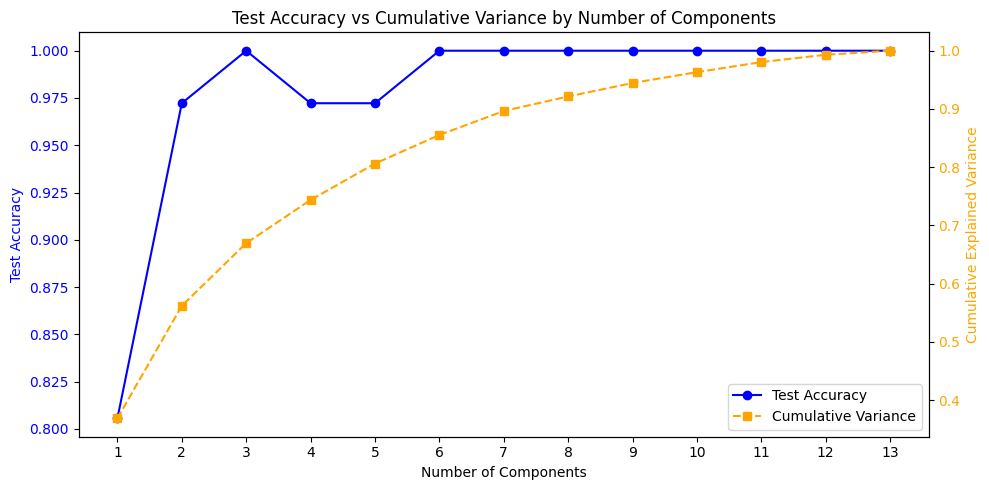

    components  test_accuracy  cumulative_variance
0            1       0.805556             0.368841
1            2       0.972222             0.562025
2            3       1.000000             0.669554
3            4       0.972222             0.743774
4            5       0.972222             0.806233
5            6       1.000000             0.855323
6            7       1.000000             0.896496
7            8       1.000000             0.921455
8            9       1.000000             0.944544
9           10       1.000000             0.963185
10          11       1.000000             0.980503
11          12       1.000000             0.993031
12          13       1.000000             1.000000


In [8]:
def components_experiment(X_train, X_test, y_train, y_test, component_range):
    results = []
    
    pca_full = PCA(n_components=13)
    pca_full.fit(X_train)
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    for n in component_range:
        _, _, acc = train_and_evaluate(X_train, X_test, y_train, y_test, n)
        results.append({
            'components': n,
            'test_accuracy': acc,
            'cumulative_variance': cumulative_variance[n-1]
        })
    
    df_results = pd.DataFrame(results)
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    ax1.plot(df_results['components'], df_results['test_accuracy'], 
             marker='o', color='blue', label='Test Accuracy')
    ax1.set_xlabel('Number of Components')
    ax1.set_ylabel('Test Accuracy', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(list(component_range))
    
    ax2 = ax1.twinx()
    ax2.plot(df_results['components'], df_results['cumulative_variance'], 
             marker='s', color='orange', linestyle='--', label='Cumulative Variance')
    ax2.set_ylabel('Cumulative Explained Variance', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
    
    plt.title('Test Accuracy vs Cumulative Variance by Number of Components')
    plt.tight_layout()
    plt.show()
    
    return df_results

# Trade-off discussion: With very few components (1-2), accuracy is low because
# we've removed too much information,where accuracy jumps up around 3-5 components
# and then plateaus after that this shows the point of diminishing returns when adding
# more components doesn't improve accuracy but increases dimensionality.


df_results = components_experiment(X_train, X_test, y_train, y_test, range(1, 14))
print(df_results)


c) plot_decision_boundaries()- this function visualises decision boundary using meshgrid and contourf on 2 components with actual data points on it.

observation: LR draws straight line boundaries since it is linear classfier. Training plot with 2 components show some overlap exists. Overall ~97% accuracy with 2 componets. Class 1 is well separated.

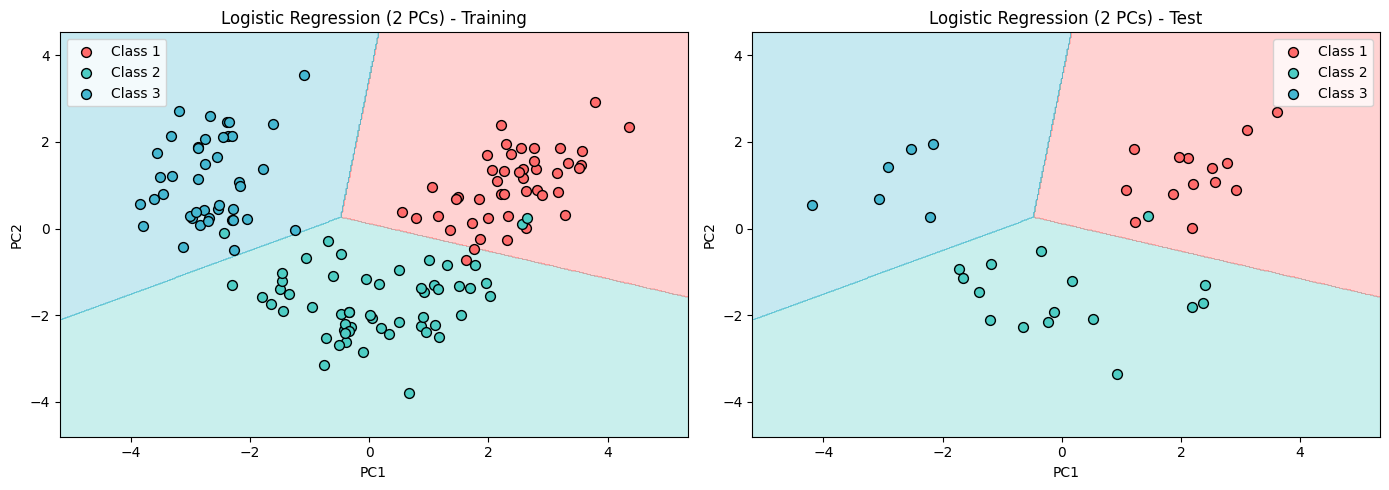

In [9]:
from matplotlib.colors import ListedColormap

def plot_decision_boundaries(X_train_2d, y_train, X_test_2d, y_test, classifier, title_prefix):
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    cmap = ListedColormap(colors)

    X_all = np.vstack([X_train_2d, X_test_2d])
    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, X_2d, y, title in [
        (ax1, X_train_2d, y_train, f"{title_prefix} - Training"),
        (ax2, X_test_2d,  y_test,  f"{title_prefix} - Test")
    ]:
        Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
        
        for idx, cls in enumerate(np.unique(y)):
            mask = y == cls
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                      color=colors[idx], label=f'Class {cls}', edgecolors='k', s=50)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_title(title)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

clf_2d = LogisticRegression(random_state=0)
clf_2d.fit(X_train_2d, y_train)

plot_decision_boundaries(X_train_2d, y_train, X_test_2d, y_test, clf_2d, "Logistic Regression (2 PCs)")


## Question 3 - PCA Interpretation and Classifier Comparision

a)plot_pca_loadings(): This function creates a heatmap of PCA loadings showing how much each original feature contributes to each component, and shows a biplot overlaying 
loading arrows on the 2D pca scatter.

Observation: PC1 is dirven by all quality based componets whereas PC2 is driven by body and stength based components.Biplot shows in class 1 quality based fetaures dominate while class 3 has both quality based na body/strength based features have low influencs

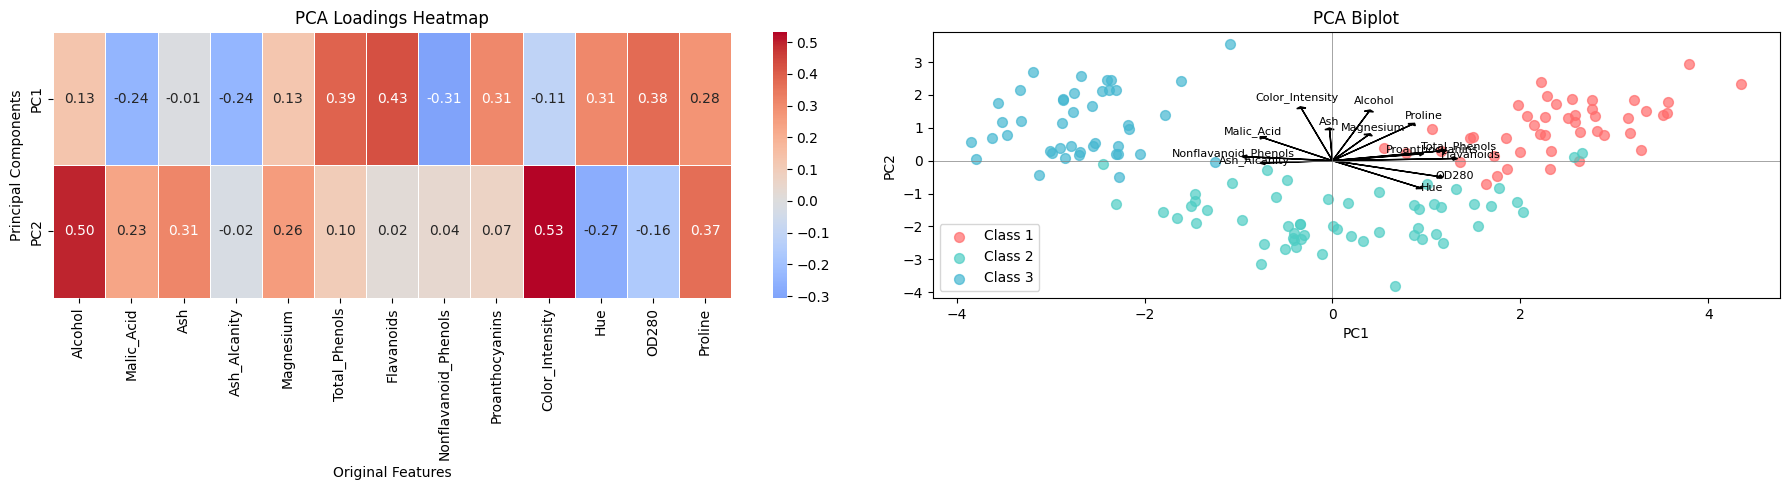

In [10]:
import seaborn as sns

def plot_pca_loadings(pca, feature_names, n_components=2):
    loadings = pca.components_[:n_components]
    loadings_df = pd.DataFrame(loadings, 
                                columns=feature_names,
                                index=[f'PC{i+1}' for i in range(n_components)])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    
    sns.heatmap(loadings_df, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax1, linewidths=0.5)
    ax1.set_title('PCA Loadings Heatmap')
    ax1.set_xlabel('Original Features')
    ax1.set_ylabel('Principal Components')
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    classes = np.unique(y_train)
    
    for idx, cls in enumerate(classes):
        mask = y_train == cls
        ax2.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   color=colors[idx], label=f'Class {cls}', alpha=0.7, s=50)
    
    scale = 3
    for i, feature in enumerate(feature_names):
        ax2.arrow(0, 0, loadings[0, i]*scale, loadings[1, i]*scale,
                 head_width=0.1, head_length=0.05, fc='black', ec='black')
        ax2.text(loadings[0, i]*scale*1.15, loadings[1, i]*scale*1.15,
                feature, fontsize=8, ha='center')
    
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_title('PCA Biplot')
    ax2.legend()
    ax2.axhline(0, color='grey', linewidth=0.5)
    ax2.axvline(0, color='grey', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
# PC1 is dominated by Flavanoids (0.43), Total_Phenols (0.39), OD280 (0.38) which are all quality related compounds
# PC2 is dominated by Color_Intensity (0.53) and Alcohol (0.50) features related to wine body and strength.

feature_names = pd.read_csv("data/Wine.csv").columns[:-1]
plot_pca_loadings(pca_2d, feature_names, n_components=2)


## Q3b - compare_classifiers

This function applies PCA with n_components, then trains and evaluates three classifiers — Logistic Regression, SVC (RBF kernel), and KNN — with 10-fold cross validation on the training set.

**Results (10 components):**

| Classifier | Test Accuracy | CV Mean | CV Std |
|---|---|---|---|
| Logistic Regression | 100% | 96.5% | 0.035 |
| SVC (RBF) | 100% | 97.9% | 0.032 |
| KNN | 97.2% | 95.8% | 0.072 |

**Observations:**
- All three classifiers achieve high test accuracy — Wine is a well-separated dataset
- SVC is the best overall: highest CV mean (97.9%) and lowest CV std (0.032) — most consistent across folds
- KNN has the highest CV std (0.072) — nearly double SVC, meaning it is sensitive to how the data is split and inconsistent across folds

**Decision Boundaries (2 PCs):**
- Logistic Regression draws straight linear boundaries — it is a linear classifier that can only separate classes with hyperplanes
- SVC draws curved boundaries thanks to the RBF kernel, which maps data into higher dimensions to find non-linear separation that better follows the natural shape of the data
- KNN has jagged irregular boundaries — it does not learn a global boundary but instead votes based on 5 nearest neighbors locally, making it sensitive to noise

**Best classifier:** SVC — highest and most consistent CV performance, and curved boundaries that naturally follow the shape of the wine class clusters.


Classifier Comparison
          Classifier  Test Accuracy  CV Mean Accuracy  CV Std
  LogisticRegression         1.0000            0.9648  0.0353
                 SVC         1.0000            0.9790  0.0320
KNeighborsClassifier         0.9722            0.9581  0.0716


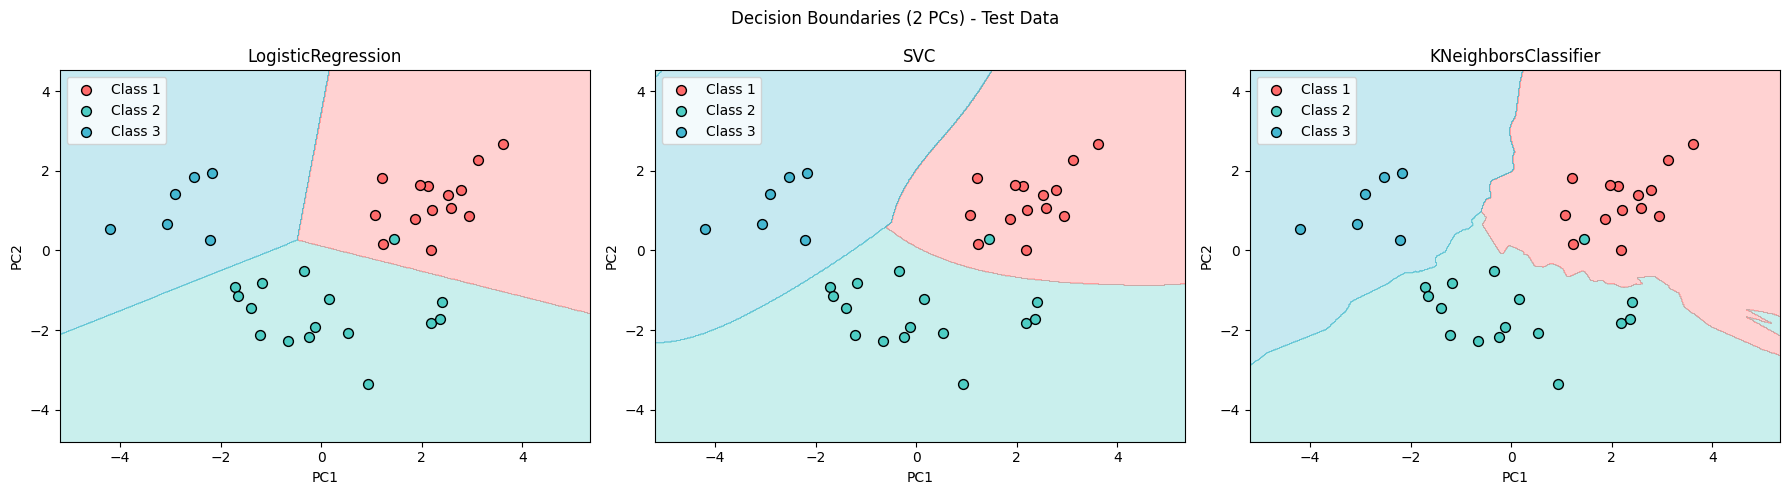

In [11]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def compare_classifiers(X_train, X_test, y_train, y_test, n_components):
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    classifiers = {
        'LogisticRegression': LogisticRegression(random_state=0),
        'SVC':                SVC(kernel='rbf', random_state=0),
        'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5)
    }
    
    summary = []
    
    for name, clf in classifiers.items():
        clf.fit(X_train_pca, y_train)
        test_acc = accuracy_score(y_test, clf.predict(X_test_pca))
        cv_scores = cross_val_score(clf, X_train_pca, y_train, cv=10)
        summary.append({
            'Classifier':       name,
            'Test Accuracy':    round(test_acc, 4),
            'CV Mean Accuracy': round(cv_scores.mean(), 4),
            'CV Std':           round(cv_scores.std(), 4)
        })
    
    summary_df = pd.DataFrame(summary)
    print("\nClassifier Comparison")
    print(summary_df.to_string(index=False))
    
    pca_2d = PCA(n_components=2)
    X_train_2d = pca_2d.fit_transform(X_train)
    X_test_2d  = pca_2d.transform(X_test)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    cmap = ListedColormap(colors)
    
    X_all = np.vstack([X_train_2d, X_test_2d])
    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, (name, _) in zip(axes, classifiers.items()):
        clf_2d = classifiers[name].__class__(**classifiers[name].get_params())
        clf_2d.fit(X_train_2d, y_train)
        
        Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
        
        for idx, cls in enumerate(np.unique(y_test)):
            mask = y_test == cls
            ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                      color=colors[idx], label=f'Class {cls}', edgecolors='k', s=50)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_title(name)
        ax.legend()
    
    plt.suptitle('Decision Boundaries (2 PCs) - Test Data')
    plt.tight_layout()
    plt.show()
    
    return summary_df

summary_df = compare_classifiers(X_train, X_test, y_train, y_test, n_components=10)
